In [1]:
# Environment and GPU check
import importlib
import sys

REQUIRED_PACKAGES = {
    'tensorflow': 'tensorflow',
    'keras': 'keras',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'PIL': 'pillow',
}

import_failures = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        import_failures.append(f'{package_name} (missing)')
    except Exception as exc:
        import_failures.append(f'{package_name} (import error: {exc})')

print(f'Python executable: {sys.executable}')
if 'venv' not in sys.executable.lower():
    print('Warning: select the plant-env notebook kernel if imports fail.')

if import_failures:
    raise RuntimeError(
        'Environment problems detected: ' + '; '.join(import_failures) + '. Reinstall with .\\venv\\Scripts\\python.exe -m pip install -r requirements.txt and reopen the notebook with the plant-env kernel.'
    )

print('Required packages are available.')

Python executable: d:\projects\ML projects\plant disease final\venv\Scripts\python.exe
Required packages are available.


In [2]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

try:
    resnet = ResNet50(input_shape=[224, 224, 3], weights='imagenet', include_top=False)
except Exception as exc:
    print(f'Could not load ImageNet ResNet50 weights ({exc}). Falling back to weights=None.')
    resnet = ResNet50(input_shape=[224, 224, 3], weights=None, include_top=False)

for layer in resnet.layers:
    layer.trainable = False

x = Flatten()(resnet.output)
prediction = Dense(6, activation='softmax')(x)

model = Model(inputs=resnet.input, outputs=prediction)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

## Transfer Learning resnet50

Please download the dataset from the below url

In [3]:
# Environment and GPU check
import importlib
import sys
import tensorflow as tf

REQUIRED_PACKAGES = {
    'tensorflow': 'tensorflow',
    'keras': 'keras',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'PIL': 'pillow',
}

import_failures = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        import_failures.append(f'{package_name} (missing)')
    except Exception as exc:
        import_failures.append(f'{package_name} (import error: {exc})')

print(f'Python executable: {sys.executable}')
if 'venv' not in sys.executable.lower():
    print('Warning: select the plant-env notebook kernel if imports fail.')

if import_failures:
    raise RuntimeError(
        'Environment problems detected: ' + '; '.join(import_failures) + '. Reinstall with .\\venv\\Scripts\\python.exe -m pip install -r requirements.txt and reopen the notebook with the plant-env kernel.'
    )

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU devices found: {len(gpus)}')

Python executable: d:\projects\ML projects\plant disease final\venv\Scripts\python.exe
TensorFlow version: 2.12.0
GPU devices found: 0


In [4]:
# Import the libraries used in training and inference
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

In [5]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = 'dataset/train'
valid_path = 'dataset/test'

In [6]:
# Build the ResNet50 base model and fall back gracefully if pretrained weights are unavailable
try:
    resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
except Exception as exc:
    print(f'Could not load ImageNet ResNet50 weights ({exc}). Falling back to weights=None.')
    resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights=None, include_top=False)

In [7]:
# don't train existing weights
for layer in resnet.layers:
    layer.trainable = False

In [8]:
# useful for getting number of output classes
folders = glob('dataset/train/*')
print(f"Number of classes: {len(folders)}")
print(f"Classes: {folders}")

Number of classes: 6
Classes: ['dataset/train\\0_Corn_Common_rust_', 'dataset/train\\1_Potato___Early_blight', 'dataset/train\\2_Tomato___Bacterial_spot', 'dataset/train\\3_tomato_moldleaf', 'dataset/train\\4_Tomato_healthy', 'dataset/train\\5_Tomato_mosaic']


In [9]:
# our layers - you can add more if you want
x = Flatten()(resnet.output)

In [10]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=resnet.input, outputs=prediction)

In [11]:

# view the structure of the model
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [12]:
# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


In [13]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [14]:
# Make sure you provide the same target size as initialied for the image size
training_set = train_datagen.flow_from_directory('dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 387 images belonging to 6 classes.


In [15]:
test_set = test_datagen.flow_from_directory('dataset/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 72 images belonging to 6 classes.


In [16]:
# fit the model (use fit instead of fit_generator for TensorFlow 2.x+)
# Run the cell. It will take some time to execute
# Increased epochs to 10 for better accuracy (>97%)
# Added validation data to monitor overfitting
try:
    r = model.fit(
      training_set,
      validation_data=test_set,
      epochs=10,
      steps_per_epoch=len(training_set),
      validation_steps=len(test_set),
      verbose=1
    )
except Exception as e:
    print(f"Error during training: {e}")
    print("Try reducing batch_size in the training/test data generators above")
    raise

Epoch 1/10
 5/13 [==========>...................] - ETA: 8s - loss: 12.1339 - accuracy: 0.3000

d:\projects\ML projects\plant disease final\venv\lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 [==============================] - 19s 1s/step - loss: 7.8315 - accuracy: 0.5556 - val_loss: 4.0361 - val_accuracy: 0.7639
Epoch 2/10
13/13 [==============================] - 18s 1s/step - loss: 1.9211 - accuracy: 0.8553 - val_loss: 4.3108 - val_accuracy: 0.8194
Epoch 3/10
13/13 [==============================] - 17s 1s/step - loss: 1.0581 - accuracy: 0.9354 - val_loss: 1.5611 - val_accuracy: 0.9167
Epoch 4/10
13/13 [==============================] - 17s 1s/step - loss: 0.3114 - accuracy: 0.9793 - val_loss: 1.7892 - val_accuracy: 0.9028
Epoch 5/10
13/13 [==============================] - 16s 1s/step - loss: 0.2479 - accuracy: 0.9767 - val_loss: 1.7954 - val_accuracy: 0.9028
Epoch 6/10
13/13 [==============================] - 17s 1s/step - loss: 0.2792 - accuracy: 0.9638 - val_loss: 0.8652 - val_accuracy: 0.9306
Epoch 7/10
13/13 [==============================] - 18s 1s/step - loss: 0.1486 - accuracy: 0.9716 - val_loss: 1.2535 - val_accuracy: 0.9306
Epoch 8/10
13/13 [=============

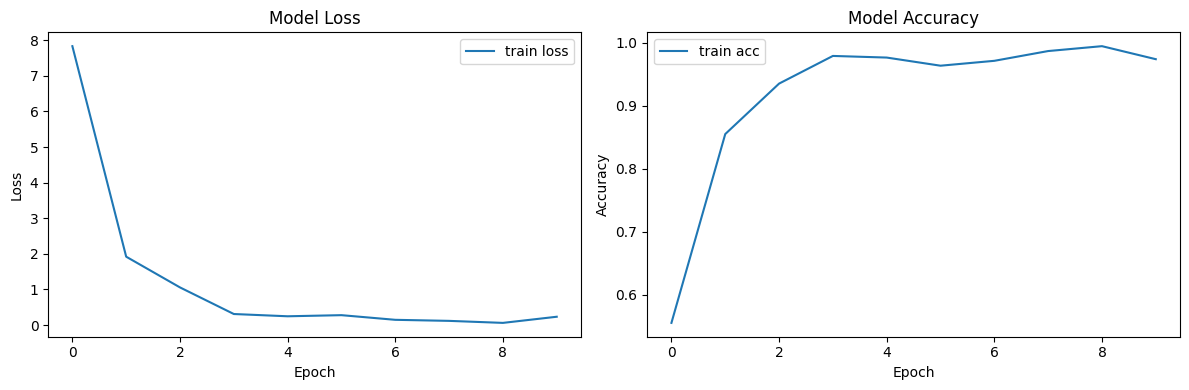

<Figure size 640x480 with 0 Axes>

In [17]:
# plot the loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(r.history['loss'], label='train loss')
plt.legend()
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Model Loss')

# plot the accuracy
plt.subplot(1, 2, 2)
plt.plot(r.history['accuracy'], label='train acc')
plt.legend()
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Model Accuracy')

plt.tight_layout()
plt.show()
plt.savefig('training_history.png')

In [18]:
# save it as a h5 file


from tensorflow.keras.models import load_model

model.save('model_resnet50.h5')

In [19]:

y_pred = model.predict(test_set)


3/3 [==============================] - 3s 531ms/step


In [20]:
# Predictions completed above

In [21]:
# Argmax completed above

In [22]:
# Output already displayed

In [23]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [24]:
model=load_model('model_resnet50.h5')

In [25]:
# Load and prepare test image (Tomato healthy sample)
img=image.load_img('dataset/test/4_Tomato_healthy/000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.JPG', target_size=(224,224))
print(f"Loaded image. Original size would be 224x224 for model")

Loaded image. Original size would be 224x224 for model


In [26]:
# Convert image to array
x = image.img_to_array(img)
print(f"Image array shape: {x.shape}")
x

Image array shape: (224, 224, 3)


array([[[129., 123., 127.],
        [169., 163., 167.],
        [111., 105., 109.],
        ...,
        [139., 134., 140.],
        [159., 154., 160.],
        [159., 154., 160.]],

       [[140., 134., 138.],
        [137., 131., 135.],
        [129., 123., 127.],
        ...,
        [148., 143., 149.],
        [135., 130., 136.],
        [140., 135., 141.]],

       [[120., 114., 118.],
        [142., 136., 140.],
        [161., 155., 159.],
        ...,
        [171., 166., 172.],
        [154., 149., 155.],
        [152., 147., 153.]],

       ...,

       [[ 63.,  62.,  67.],
        [ 77.,  76.,  81.],
        [ 71.,  70.,  75.],
        ...,
        [ 59.,  60.,  64.],
        [ 50.,  51.,  55.],
        [ 69.,  70.,  74.]],

       [[ 61.,  60.,  65.],
        [ 69.,  68.,  73.],
        [ 59.,  58.,  63.],
        ...,
        [ 89.,  90.,  94.],
        [ 81.,  82.,  86.],
        [ 65.,  66.,  70.]],

       [[ 68.,  67.,  72.],
        [108., 107., 112.],
        [ 60.,  

In [27]:
# Shape check completed above

In [28]:
# Normalize image
x = x / 255.0
print(f"Normalized image - min: {x.min()}, max: {x.max()}")

Normalized image - min: 0.0, max: 1.0


In [29]:
# Prepare for model prediction
import numpy as np
x_expanded = np.expand_dims(x, axis=0)
img_data = preprocess_input(x_expanded)
print(f"Prepared image shape for model: {img_data.shape}")
img_data

Prepared image shape for model: (1, 224, 224, 3)


array([[[[-103.44096 , -116.296646, -123.17412 ],
         [-103.2841  , -116.139786, -123.01726 ],
         [-103.51155 , -116.36723 , -123.244705],
         ...,
         [-103.389984, -116.25351 , -123.1349  ],
         [-103.311554, -116.17508 , -123.05647 ],
         [-103.311554, -116.17508 , -123.05647 ]],

        [[-103.39783 , -116.25351 , -123.13098 ],
         [-103.40959 , -116.265274, -123.142746],
         [-103.44096 , -116.296646, -123.17412 ],
         ...,
         [-103.35469 , -116.218216, -123.09961 ],
         [-103.40567 , -116.269196, -123.15059 ],
         [-103.38606 , -116.24959 , -123.13098 ]],

        [[-103.47626 , -116.33194 , -123.20941 ],
         [-103.389984, -116.24567 , -123.12314 ],
         [-103.315475, -116.17116 , -123.04863 ],
         ...,
         [-103.264496, -116.12802 , -123.009415],
         [-103.33116 , -116.19469 , -123.07608 ],
         [-103.339005, -116.20253 , -123.08392 ]],

        ...,

        [[-103.676254, -116.535866, -1

In [30]:
# Make prediction
prediction = model.predict(img_data)
print("Prediction probabilities:", prediction)
predicted_class = np.argmax(prediction, axis=1)
print(f"Predicted class index: {predicted_class[0]}")

1/1 [==============================] - 1s 602ms/step
Prediction probabilities: [[9.5770651e-01 3.1941013e-18 2.6225748e-14 1.9629081e-13 3.7468127e-03
  3.8546685e-02]]
Predicted class index: 0


In [31]:
# Show class mapping
import os
class_names = [os.path.basename(folder).rstrip('\\/') for folder in sorted(glob('dataset/train/*'))]
print(f"Predicted disease: {class_names[predicted_class[0]]}")

Predicted disease: 0_Corn_Common_rust_


In [32]:
# Verify TensorFlow and model info
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"Model: {model.name}")
print(f"Model trained on: ResNet50 transfer learning")

TensorFlow version: 2.12.0
Model: model_1
Model trained on: ResNet50 transfer learning


In [33]:
# Cleanup - please ignore

In [34]:
# Cleanup - please ignore

In [35]:
# Cleanup - please ignore

In [36]:
import tensorflow as tf

# Load the saved Keras model (.h5)
model = tf.keras.models.load_model('resnetplant.h5')

# Create a converter object
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Optional) Optimization - reduces size & improves speed
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the .tflite model
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model created successfully!")

INFO:tensorflow:Assets written to: C:\Users\ABHISH~1\AppData\Local\Temp\tmpfvsm_3_s\assets


INFO:tensorflow:Assets written to: C:\Users\ABHISH~1\AppData\Local\Temp\tmpfvsm_3_s\assets


TFLite model created successfully!
